In [1]:
from pathlib import Path  # filesystem paths
import pandas as pd  # tabular data handling
import numpy as np  # numerical arrays
import matplotlib.pyplot as plt  # plotting interface
import seaborn as sns  # statistical visualizations

from sklearn.cluster import KMeans  # k-means clustering
from sklearn.metrics import silhouette_score  # silhouette metric for clustering quality
from sklearn.decomposition import PCA  # dimensionality reduction for plotting


In [ ]:
# Paths
PROJECT_ROOT = Path().resolve().parent  # project root (one level up)
DATA_DIR = PROJECT_ROOT / "data" / "processed"  # processed data directory
PLOTS_DIR = PROJECT_ROOT / "reports" / "plots_clustering"  # clustering plots output
PLOTS_DIR.mkdir(parents=True, exist_ok=True)  # ensure output folder exists


In [3]:
# ========= 1) Load processed MAT dataset =========
df = pd.read_csv(DATA_DIR / "processed_mat.csv")  # load processed math dataset

X = df.drop(columns=["G3"])  # drop target for unsupervised clustering

print("Shape of processed feature matrix:", X.shape)  # log shape


Shape of processed feature matrix: (395, 46)


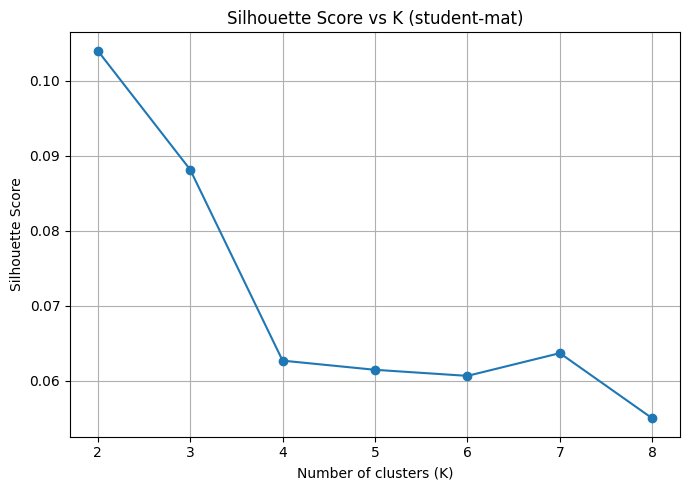

In [4]:
# ========= 2) Find optimal K using Silhouette =========
k_values = range(2, 9)  # candidate cluster counts
sil_scores = []  # store silhouette scores

for k in k_values:  # iterate cluster sizes
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")  # init model
    labels = kmeans.fit_predict(X)  # cluster assignments
    score = silhouette_score(X, labels)  # silhouette score
    sil_scores.append(score)  # collect score

plt.figure(figsize=(7,5))  # silhouette plot figure
plt.plot(k_values, sil_scores, marker="o")  # plot scores vs k
plt.title("Silhouette Score vs K (student-mat)")  # title
plt.xlabel("Number of clusters (K)")  # x label
plt.ylabel("Silhouette Score")  # y label
plt.grid(True)  # grid
plt.tight_layout()  # layout
plt.savefig(PLOTS_DIR / "silhouette_mat.png", dpi=300)  # save plot
plt.show()  # display


Best K according to silhouette: 2


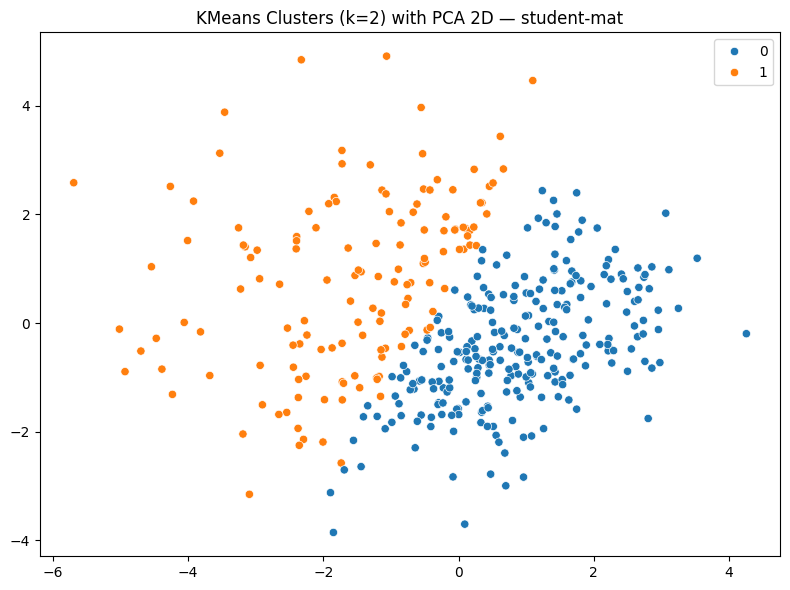

In [5]:
best_k = k_values[np.argmax(sil_scores)]  # best K by silhouette
print("Best K according to silhouette:", best_k)  # log best K

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")  # fit final model
cluster_labels = kmeans.fit_predict(X)  # final labels

df["cluster"] = cluster_labels  # attach labels to dataframe

pca = PCA(n_components=2)  # 2D PCA
X_pca = pca.fit_transform(X)  # transform features

plt.figure(figsize=(8,6))  # PCA scatter figure
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette="tab10")  # scatter by cluster
plt.title(f"KMeans Clusters (k={best_k}) with PCA 2D — student-mat")  # title
plt.tight_layout()  # layout
plt.savefig(PLOTS_DIR / f"kmeans_pca_mat_k{best_k}.png", dpi=300)  # save plot
plt.show()  # display



Cluster Feature Means:



,sex_M,address_U,famsize_LE3,Pstatus_T,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.380,0.824,0.247,0.894,0.133,0.624,0.49,0.522,0.839,0.984,...,0.106,-0.201,-0.334,-0.426,-0.495,-0.123,-0.113,0.274,0.270,0.230
1,0.643,0.693,0.364,0.900,0.121,0.593,0.40,0.486,0.714,0.886,...,-0.193,0.365,0.609,0.776,0.901,0.223,0.206,-0.498,-0.492,-0.419



Pass Rate per Cluster:



,pass_rate
cluster,
0,0.772549
1,0.485714


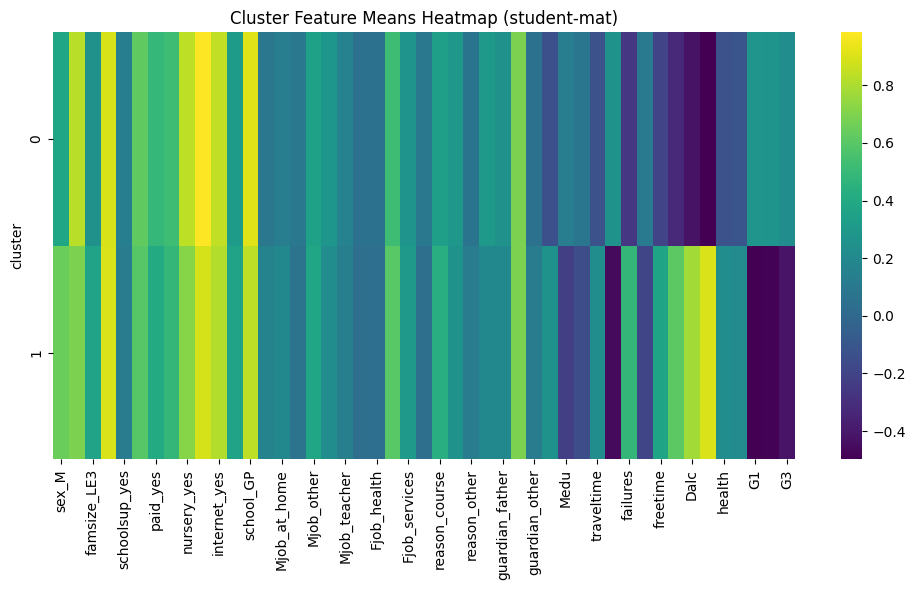

In [ ]:
cluster_summary = df.groupby("cluster").mean().round(3)  # mean feature values per cluster
print("\nCluster Feature Means:")  # header
display(cluster_summary)  # show summary

cluster_summary.to_csv(PLOTS_DIR / "cluster_feature_means_mat.csv")  # save cluster means

RAW_DIR = PROJECT_ROOT / "data" / "raw"  # raw data dir
raw_mat = pd.read_csv(RAW_DIR / "student-mat.csv", sep=";")  # load raw math

df["pass"] = (raw_mat["G3"] >= 10).astype(int)  # binary pass label

cluster_pass_rate = df.groupby("cluster")["pass"].mean().rename("pass_rate")  # pass rate per cluster

print("\nPass Rate per Cluster:")  # header
display(cluster_pass_rate.to_frame())  # show pass rates

cluster_pass_rate.to_csv(PLOTS_DIR / "cluster_pass_rate_mat.csv")  # save pass rates

plt.figure(figsize=(10,6))  # heatmap figure
sns.heatmap(cluster_summary, cmap="viridis")  # heatmap of means
plt.title("Cluster Feature Means Heatmap (student-mat)")  # title
plt.tight_layout()  # layout
plt.savefig(PLOTS_DIR / "cluster_heatmap_mat.png", dpi=300)  # save heatmap
plt.show()  # display
